---
# 📊 Análise Exploratória dos Dados do ENEM 2023

Este notebook apresenta uma análise exploratória dos microdados do ENEM 2023 com foco em desempenho acadêmico, desigualdade educacional e fatores socioeconômicos utilizando técnicas de análise exploratória de dados (EDA).

A análise utiliza Python e bibliotecas de Ciência de Dados para investigar padrões estatísticos, comparar grupos de estudantes e visualizar tendências presentes nos dados.

---
## 🎯 Objetivo do Projeto

O principal objetivo deste projeto é aplicar técnicas de análise de dados para compreender padrões de desempenho dos participantes do ENEM 2023.

Ao longo do notebook, serão investigadas questões relacionadas a:

- diferenças regionais de desempenho;
- impacto da renda familiar;
- comparação entre escolas públicas e privadas;
- influência do acesso à internet;
- distribuição das notas;
- correlação entre áreas do conhecimento.

Além da exploração estatística, o projeto busca demonstrar boas práticas de visualização e interpretação de dados utilizando Python.

---
## 📂 Sobre os Dados

Os dados utilizados nesta análise foram extraídos do dataset **Student Performance — ENEM 2023**, disponível no Kaggle.

O conjunto de dados contém informações socioeconômicas e notas dos participantes do exame, permitindo análises sobre desigualdade educacional e desempenho acadêmico no Brasil.

As principais variáveis analisadas incluem:

- estado e região;
- tipo de escola;
- renda familiar;
- sexo;
- acesso à internet;
- notas por área do conhecimento.

---
## 🛠️ Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas responsáveis pela manipulação, análise e visualização dos dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 📥 Carregamento e Preparação dos Dados

Aqui é realizado o carregamento do dataset.

Também são feitas etapas iniciais de estilização e preparação e organização dos dados.

In [2]:
# Tema global
sns.set_theme(style="whitegrid")

# Paleta de cores padrão
PALETTE = "crest"

# Carregar os dados
df = pd.read_csv('../data/ENEM_2023.csv')
print(df.shape)
df.head()

(127574, 18)


,Age,Genre,Race,School_Type,State,Region,Score_Natural_Sciences,Score_Human_Sciences,Score_Languages,Score_Mathematics,Score_Essay,Mean_Score,Father_Education,Mother_Education,Family_Income,Has_Cell_Phone,Has_Computer,Has_Internet
0,17,Female,Pardo (Mixed),Public,CE,Northeast,459.0,508.5,507.2,466.7,880.0,564.28,Incomplete Secondary (High School),Incomplete Secondary (High School),R$ 1320 - 1980,3,0,Yes
1,18,Female,Pardo (Mixed),Public,CE,Northeast,402.5,379.2,446.9,338.3,560.0,425.38,Incomplete Primary (5th grade),Incomplete Primary (5th grade),Up to R$ 1320,1,0,No
2,18,Male,Pardo (Mixed),Public,PR,South,608.2,667.6,607.9,691.9,780.0,671.12,Incomplete Secondary (High School),Complete Secondary (High School),R$ 1980 - 2640,1,1,Yes
3,19,Female,White,Public,PA,North,515.7,553.1,544.4,437.0,880.0,586.04,Complete Secondary (High School),Complete Secondary (High School),Up to R$ 1320,3,0,Yes
4,18,Male,White,Public,SP,Southeast,523.8,576.3,596.5,628.1,600.0,584.94,Incomplete Primary (9th grade),Incomplete Primary (9th grade),R$ 1980 - 2640,1,0,Yes


---
## 🔎 Visão Geral dos Dados

Antes das análises, é importante compreender a estrutura do dataset, verificar os tipos das variáveis e observar estatísticas descritivas iniciais.

In [3]:
print(df.dtypes)
print('\n')
print(df.isnull().sum())
print('\n')
df.describe()

Age                           str
Genre                         str
Race                          str
School_Type                   str
State                         str
Region                        str
Score_Natural_Sciences    float64
Score_Human_Sciences      float64
Score_Languages           float64
Score_Mathematics         float64
Score_Essay               float64
Mean_Score                float64
Father_Education              str
Mother_Education              str
Family_Income                 str
Has_Cell_Phone              int64
Has_Computer                int64
Has_Internet                  str
dtype: object


Age                       0
Genre                     0
Race                      0
School_Type               0
State                     0
Region                    0
Score_Natural_Sciences    0
Score_Human_Sciences      0
Score_Languages           0
Score_Mathematics         0
Score_Essay               0
Mean_Score                0
Father_Education          0
Mother_E

,Score_Natural_Sciences,Score_Human_Sciences,Score_Languages,Score_Mathematics,Score_Essay,Mean_Score,Has_Cell_Phone,Has_Computer
count,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000
mean,493.852424,527.929316,523.010379,540.499255,662.987756,549.655826,2.619147,0.687844
std,83.167040,83.856683,72.294725,127.663655,209.790684,94.785843,1.095255,0.915637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,439.500000,475.300000,478.400000,439.700000,560.000000,486.320000,2.000000,0.000000
50%,491.200000,534.500000,528.100000,532.700000,680.000000,551.230000,3.000000,0.000000
75%,547.600000,586.900000,573.500000,634.800000,840.000000,616.700000,3.000000,1.000000
max,844.300000,823.000000,801.100000,958.600000,1000.000000,847.060000,4.000000,4.000000


---
## 📊 Perguntas Investigadas

As análises deste notebook buscam responder às seguintes perguntas:

1. Qual o desempenho médio por região do Brasil?
2. Escolas públicas e privadas apresentam diferenças significativas?
3. Como a renda familiar influencia as notas?
4. Existem diferenças de desempenho entre homens e mulheres?
5. Como as notas de Matemática estão distribuídas?
6. Como os estados do Nordeste se comparam ao restante do Brasil?
7. O acesso à internet impacta o desempenho?
8. Existe correlação entre Redação e Matemática?

---
## 🌎 Desempenho Médio por Região

Nesta análise, investigamos como o desempenho médio dos estudantes varia entre as regiões do Brasil.

O objetivo é identificar possíveis desigualdades regionais no desempenho acadêmico.

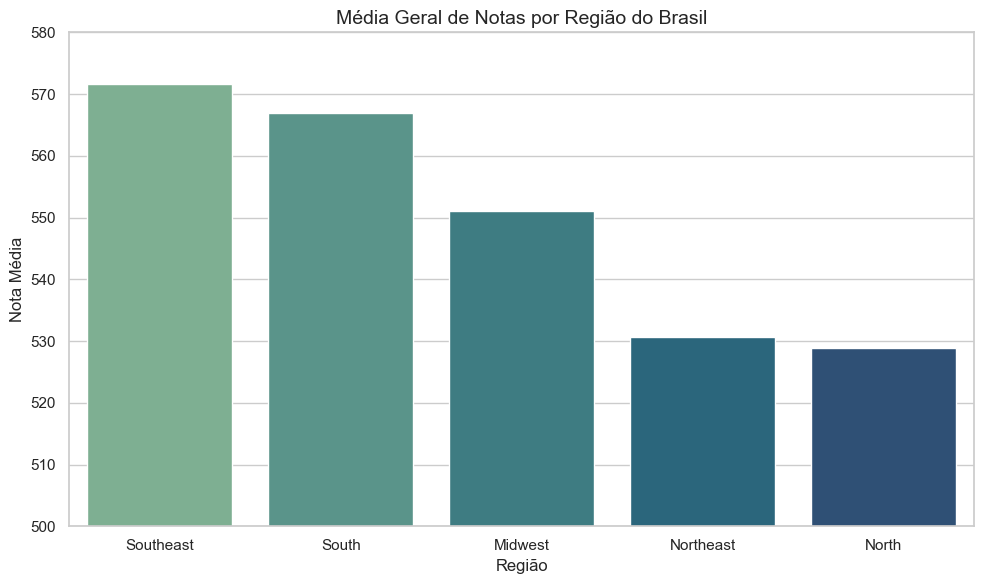

In [4]:
media_por_regiao = df.groupby('Region')['Mean_Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=media_por_regiao, x='Region', y='Mean_Score', hue='Region', legend=False, palette=PALETTE)
plt.title('Média Geral de Notas por Região do Brasil', fontsize=14)
plt.ylabel('Nota Média')
plt.xlabel('Região')
plt.ylim(500, 580) 
plt.tight_layout()
plt.show()

**Interpretação:** O Sudeste lidera com 571 pontos, seguido do Sul com 566. 
Norte e Nordeste ficam abaixo de 531, com diferença de ~43 pontos em relação 
ao topo — quase meio desvio padrão. Isso reflete desigualdades históricas de 
acesso à educação de qualidade entre as regiões.

---
## 🏫 Escola Pública vs Escola Privada

Nesta etapa, comparamos o desempenho médio em Matemática entre estudantes de escolas públicas e privadas.

Essa análise permite observar possíveis impactos das diferenças estruturais entre os sistemas de ensino.

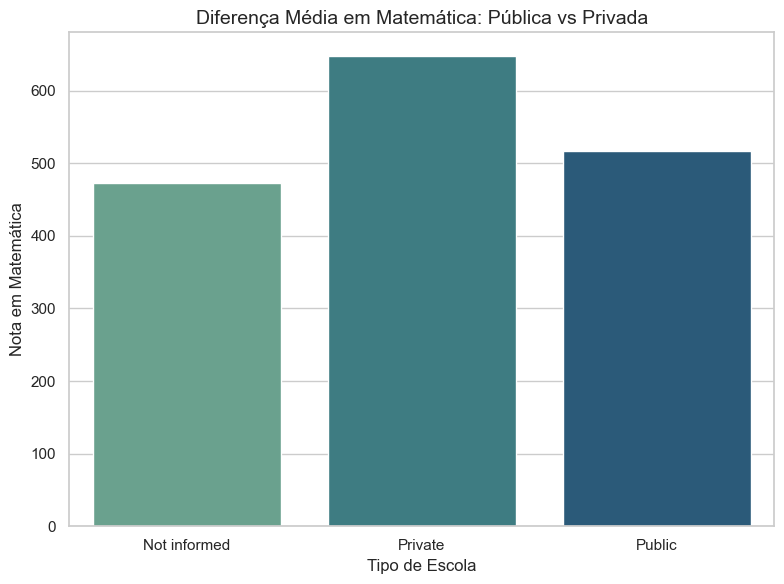


A diferença real é de 130.38 pontos.


In [5]:
media_mat_por_tipo_escola = df.groupby('School_Type')['Score_Mathematics'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=media_mat_por_tipo_escola, x='School_Type', y='Score_Mathematics', hue='School_Type', legend=False, palette=PALETTE)
plt.title('Diferença Média em Matemática: Pública vs Privada', fontsize=14)
plt.ylabel('Nota em Matemática')
plt.xlabel('Tipo de Escola')
plt.tight_layout()
plt.show()

# Cálculo da diferença real entre as médias de Matemática para escolas privadas e públicas
diferenca = media_mat_por_tipo_escola.set_index('School_Type').loc['Private', 'Score_Mathematics'] - \
            media_mat_por_tipo_escola.set_index('School_Type').loc['Public', 'Score_Mathematics']
print(f"\nA diferença real é de {diferenca:.2f} pontos.")

**Interpretação:** Alunos de escolas privadas superam os de escolas públicas 
em 130 pontos em Matemática — uma diferença expressiva. A categoria 
"Not informed" apresenta nota inferior até à pública, possivelmente 
representando alunos em situação irregular ou com dados incompletos.

---
## 💰 Impacto da Renda Familiar

A renda familiar é um dos fatores mais relevantes em estudos sobre desempenho acadêmico.

Nesta análise, investigamos como diferentes faixas de renda se relacionam com as notas médias dos estudantes.

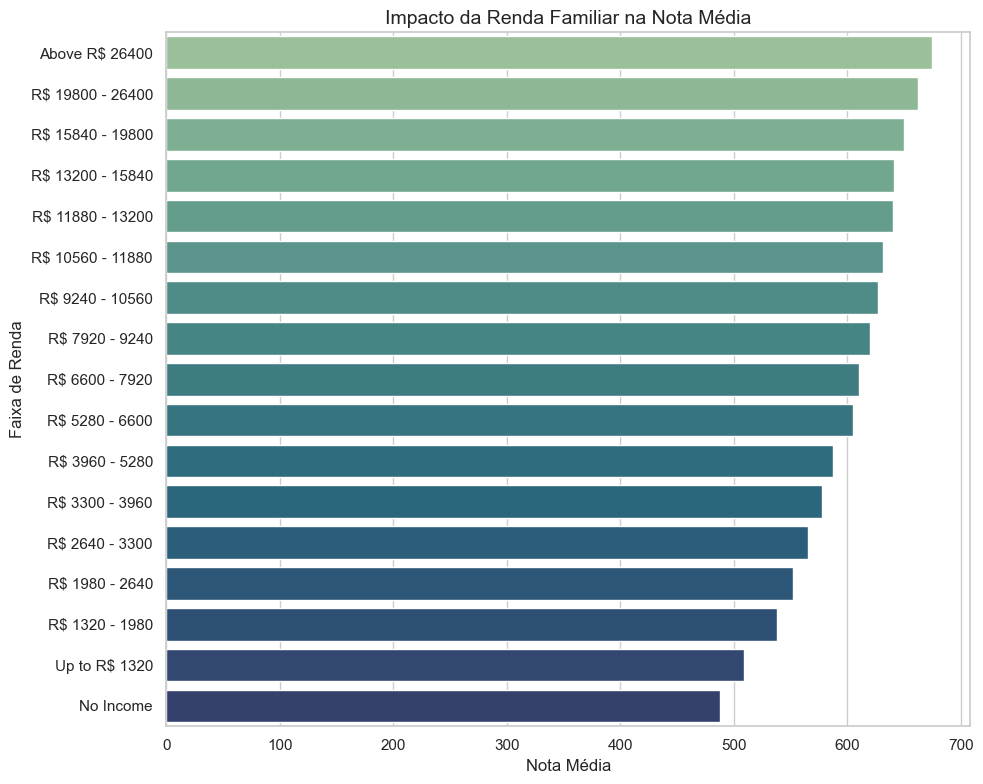

In [6]:
media_por_faixa_renda = df.groupby('Family_Income')['Mean_Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=media_por_faixa_renda, x='Mean_Score', y='Family_Income', hue='Family_Income', legend=False, palette=PALETTE)
plt.title('Impacto da Renda Familiar na Nota Média', fontsize=14)
plt.xlabel('Nota Média')
plt.ylabel('Faixa de Renda')
plt.tight_layout()
plt.show()

**Interpretação:** Há uma relação clara e direta entre renda e desempenho. 
Alunos com renda acima de R$ 26.400 têm média de 674 pontos, enquanto os 
de menor renda ficam abaixo de 500. A diferença entre o topo e a base é de 
aproximadamente 175 pontos — mais de dois desvios padrão.

---
## 👥 Comparação de Desempenho por Sexo

Nesta seção, analisamos possíveis diferenças de desempenho entre homens e mulheres nas áreas avaliadas pelo ENEM.

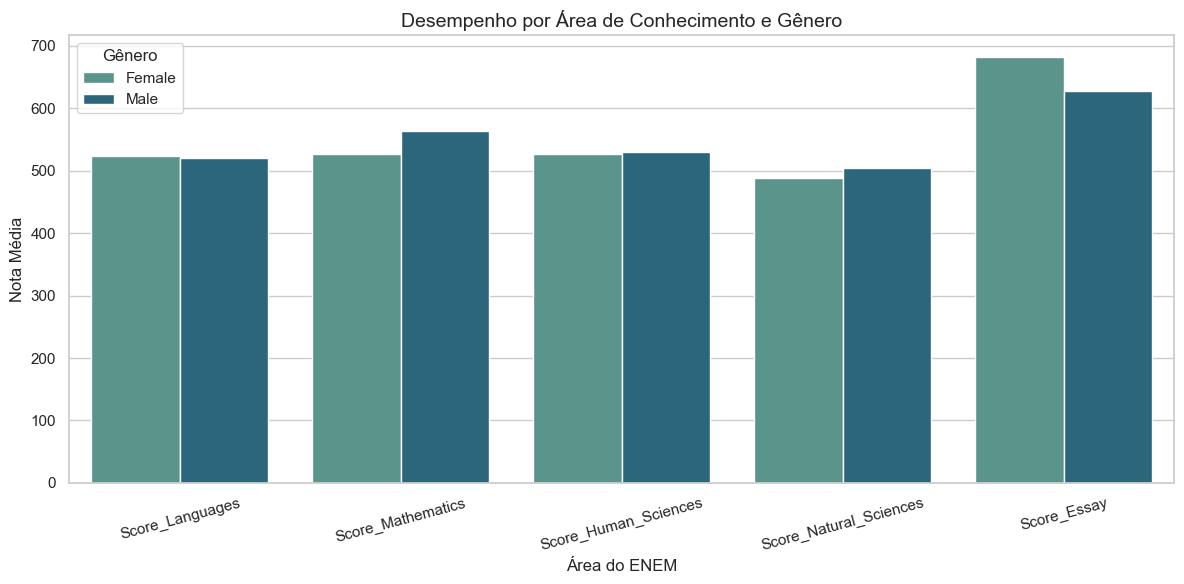

In [7]:
colunas_notas = ['Score_Languages', 'Score_Mathematics', 'Score_Human_Sciences', 'Score_Natural_Sciences', 'Score_Essay']
medias_por_genero = df.groupby('Genre')[colunas_notas].mean().reset_index()

# Transformando os dados para o formato "longo" exigido pelo Seaborn
df_plot = medias_por_genero.melt(id_vars='Genre', var_name='Área', value_name='Nota')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Área', y='Nota', hue='Genre', palette=PALETTE)
plt.title('Desempenho por Área de Conhecimento e Gênero', fontsize=14)
plt.ylabel('Nota Média')
plt.xlabel('Área do ENEM')
plt.xticks(rotation=15)
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

**Interpretação:** Homens têm desempenho superior em Matemática
e Ciências da Natureza. Mulheres se saem melhor em Redação e Linguagens. 
Essa diferença por área levanta questões sobre influências culturais 
no aprendizado.

---
## 📈 Distribuição das Notas em Matemática

A distribuição das notas permite identificar padrões de concentração, dispersão e possíveis valores extremos entre os participantes.

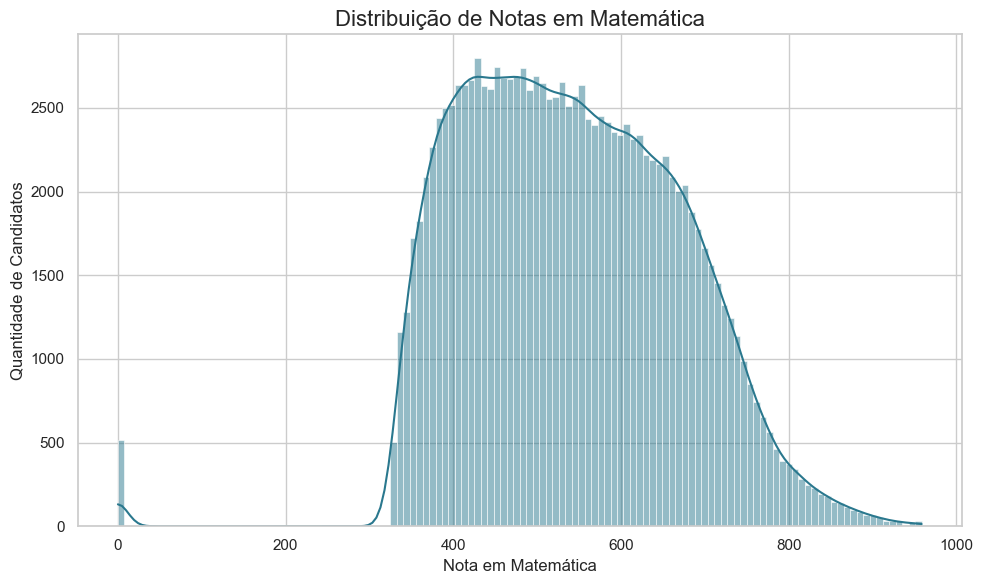

In [8]:
# 1. Definindo o tamanho da imagem
plt.figure(figsize=(10, 6))

# 2. Criando o histograma com a linha de densidade (KDE)
sns.histplot(data=df, x='Score_Mathematics', bins='auto', kde=True, color='#2A788E')

# 3. Adicionando título e rótulos
plt.title('Distribuição de Notas em Matemática', fontsize=16)
plt.xlabel('Nota em Matemática', fontsize=12)
plt.ylabel('Quantidade de Candidatos', fontsize=12)

plt.tight_layout()
plt.show()

**Interpretação:** A distribuição das notas de Matemática revela um pico expressivo no valor zero, que representa candidatos ausentes ou que zeraram a prova, seguido por um vácuo de pontuações até aproximadamente os 320 pontos. Essa lacuna é um reflexo da Teoria de Resposta ao Item (TRI), que torna estatisticamente improvável obter notas muito baixas (mas acima de zero) quando há o mínimo de coerência nos acertos. A maior parte dos participantes concentra-se na faixa entre 400 e 650 pontos, com uma redução gradual na frequência conforme as notas avançam para a extremidade superior da escala.

---
## 🌵 Estados do Nordeste vs Restante do Brasil

Nesta análise, comparamos o desempenho médio dos estados da região Nordeste com o restante do país.

O objetivo é investigar possíveis diferenças regionais de desempenho e observar como fatores históricos, econômicos e sociais podem estar relacionados aos resultados educacionais.

NE_vs_Resto
Nordeste           530.597279
Resto do Brasil    561.671945
Name: Mean_Score, dtype: float64


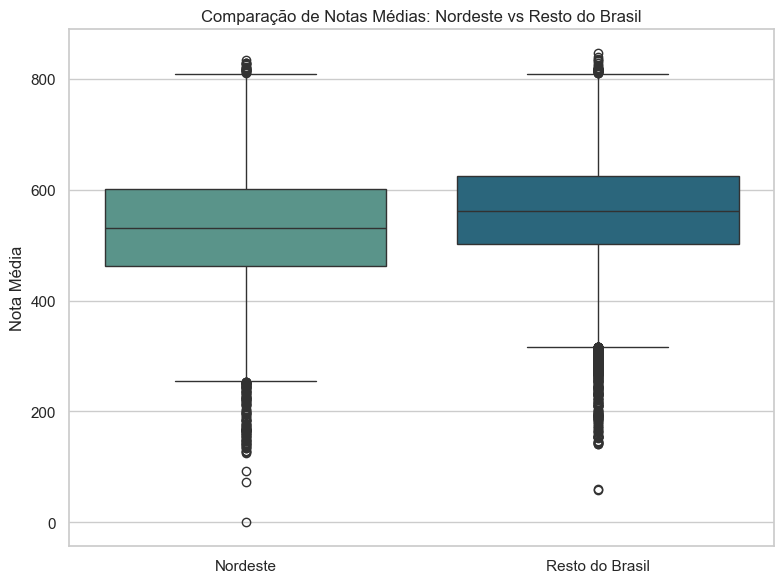

In [9]:
# 1. Criando a variável de comparação
df['NE_vs_Resto'] = df['Region'].apply(lambda x: 'Nordeste' if x == 'Northeast' else 'Resto do Brasil')

# 2. Comparando as médias de forma rápida
comparativo = df.groupby('NE_vs_Resto')['Mean_Score'].mean()
print(comparativo)

# 3. Visualizando a distribuição com Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='NE_vs_Resto', y='Mean_Score', 
            hue='NE_vs_Resto', legend=False, palette=PALETTE)
plt.title('Comparação de Notas Médias: Nordeste vs Resto do Brasil')
plt.xlabel('')
plt.ylabel('Nota Média')
plt.tight_layout()
plt.show()

**Interpretação:** O Nordeste tem média de 530 pontos contra 561 do restante 
do Brasil — diferença de 31 pontos. O boxplot revela que não é só a média 
que difere: a dispersão e os valores extremos também são distintos, 
sugerindo maior desigualdade interna nas outras regiões.

---
## 🌐 Impacto do Acesso à Internet

Aqui avaliamos se o acesso à internet em casa apresenta relação com o desempenho acadêmico dos estudantes.

Has_Internet
No     494.479994
Yes    554.363457
Name: Mean_Score, dtype: float64

A diferença média é de 59.88 pontos entre quem tem e quem não tem internet em casa.
A diferença percentual é de 12.11% a mais para quem tem internet em casa.


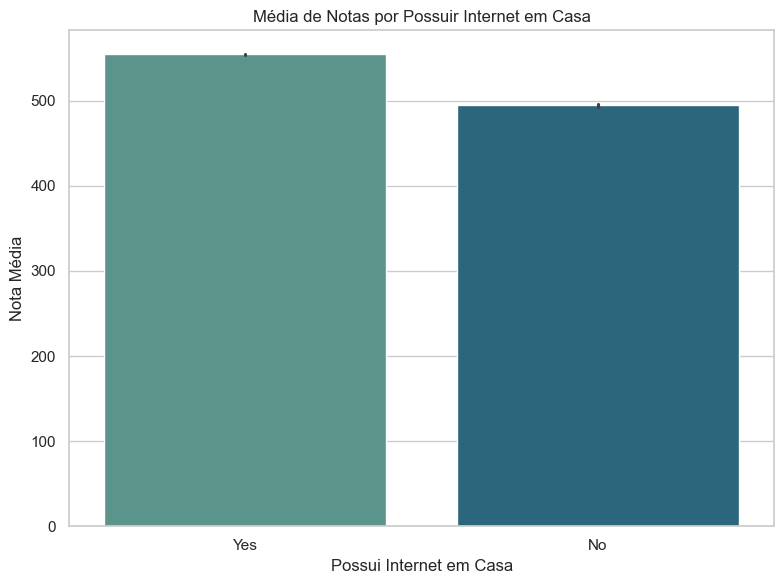

In [10]:
medias_por_possuir_internet = df.groupby('Has_Internet')['Mean_Score'].mean()
print(medias_por_possuir_internet)

# Quantificando a diferença
diferenca_pontos = medias_por_possuir_internet['Yes'] - medias_por_possuir_internet['No']
print(f"\nA diferença média é de {diferenca_pontos:.2f} pontos entre quem tem e quem não tem internet em casa.")

diferenca_percentual = (diferenca_pontos / medias_por_possuir_internet['No']) * 100
print(f"A diferença percentual é de {diferenca_percentual:.2f}% a mais para quem tem internet em casa.")

# Visualizando a diferença
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Has_Internet', y='Mean_Score',
            hue='Has_Internet', legend=False, palette=PALETTE)
plt.title('Média de Notas por Possuir Internet em Casa')
plt.xlabel('Possui Internet em Casa')
plt.ylabel('Nota Média')
plt.tight_layout()
plt.show()

**Interpretação:** Ter internet em casa está associado a uma diferença de 
quase 60 pontos na nota média — 12% superior. Isso não prova causalidade 
(alunos com internet tendem a ter melhor condição socioeconômica geral), 
mas evidencia que o acesso digital é um marcador relevante de desigualdade 
educacional.

---
## 🔗 Correlação entre Redação e Matemática

Nesta análise, investigamos a relação entre as notas de Redação e Matemática para verificar se estudantes com bom desempenho em uma área tendem a apresentar desempenho semelhante na outra.

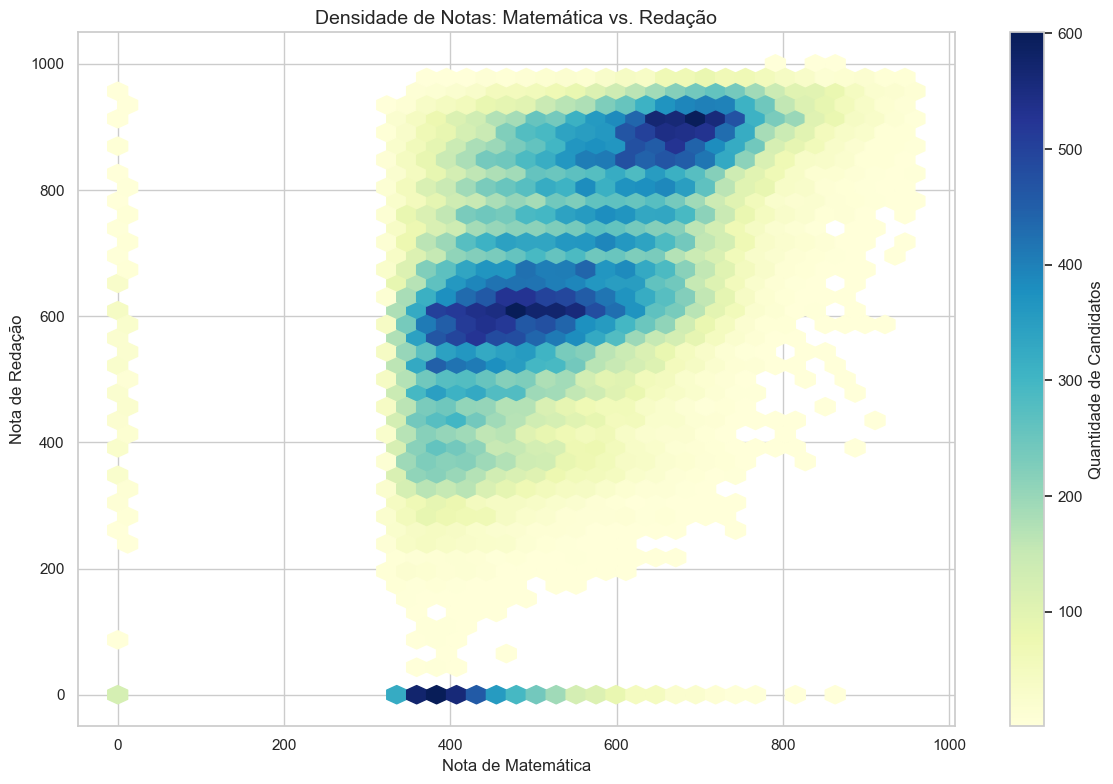

In [11]:
# 1. Definindo o tamanho da figura
plt.figure(figsize=(12, 8))

# 2. Criando o gráfico de hexágonos
hb = plt.hexbin(
    df['Score_Mathematics'], 
    df['Score_Essay'], 
    gridsize=40, 
    cmap='YlGnBu', 
    mincnt=1
)

# 3. Adicionando uma barra de cores para servir de legenda
cb = plt.colorbar(hb)
cb.set_label('Quantidade de Candidatos', fontsize=12)

# 4. Personalizando títulos e eixos
plt.title('Densidade de Notas: Matemática vs. Redação', fontsize=14)
plt.xlabel('Nota de Matemática', fontsize=12)
plt.ylabel('Nota de Redação', fontsize=12)

plt.tight_layout()
plt.show()

**Interpretação:** O hexbin revela uma correlação positiva moderada entre 
Matemática e Redação — alunos que vão bem em um tendem a ir bem no outro. 
A concentração maior está na faixa de 400–650 em Matemática e 500–800 em 
Redação. Os zeros em ambos os eixos representam alunos ausentes ou que 
zeraram.

---
# ✅ Conclusão

A análise dos microdados do ENEM 2023 revelou padrões consistentes de desigualdade educacional no Brasil, evidenciando a forte influência de fatores socioeconômicos no desempenho acadêmico dos estudantes.

---

## 📌 Principais Resultados

- **Desigualdade regional:** Sudeste e Sul apresentaram médias superiores às regiões Norte e Nordeste em aproximadamente 43 pontos.

- **Tipo de escola:** Estudantes de escolas privadas superaram os de escolas públicas em cerca de 130 pontos na prova de Matemática.

- **Renda familiar:** Foi observada uma relação direta entre renda e desempenho, com diferença aproximada de 175 pontos entre as menores e maiores faixas de renda.

- **Acesso à internet:** Participantes com acesso à internet em casa apresentaram desempenho médio cerca de 12% superior.

- **Gênero:** Foram identificadas diferenças de desempenho por área do conhecimento, com homens apresentando melhores médias em exatas e mulheres em Linguagens e Redação.

---

## 🔎 Interpretação Geral

Os fatores analisados demonstram forte correlação entre si. Regiões com menor renda média tendem a apresentar menor acesso à internet, menor presença de escolas privadas e desempenho acadêmico inferior.

Nesse contexto, o ENEM funciona também como um retrato das desigualdades socioeconômicas presentes no Brasil.

---

## 🛠️ Habilidades Demonstradas no Projeto

Além da investigação de dados educacionais reais, este projeto também demonstra a aplicação prática de:

- análise exploratória de dados (EDA);
- manipulação de dados com Pandas;
- visualização estatística com Seaborn e Matplotlib;
- interpretação analítica de dados;
- comunicação de resultados através de visualizações.

---

## 🚀 Considerações Finais

Os resultados reforçam como fatores estruturais e socioeconômicos possuem impacto significativo no desempenho acadêmico dos estudantes brasileiros.

Este projeto evidencia como técnicas de Ciência de Dados podem ser utilizadas para transformar dados públicos em análises relevantes sobre educação e desigualdade social.

---